# Introdução 

Este notebook tem a finalidade de apresentar um caso de estudos sobre diversificação de produtos em uma carteira de investimentos.

O caso apresentado aqui é focado na montagem de uma carteira de criptomoedas, entretanto seus conceitos podem ser aplicados a qualquer produtos de investimento, sejam ações, fundos, títulos públicos, debêntures, aplicações imobiliárias, etc.

## Carteira de investimentos

Uma carteira de investimentos é um grupo de ativos que pertence a um determinado investidor, seja pessoa física ou jurídica. Também chamada de **cesta** ou **portfólio de investimentos**, ela reúne ativos financeiros que podem pertencer a uma categoria de investimento.

A carteira permite a **diversificação** de ativos que tem como objetivo (mas não necessariamente) fornecer menos riscos ao investidor, pois o mesmo não confia seu dinheiro em apenas um único produto. Além disso, como apresentado neste notebook, tem o potencial de aumentar seus retornos.

As criptomoedas utilizadas são:

| Simbolo | Nome         |
|---------|--------------|
| BTC     | Bitcoin      |
| ETH     | Ethereum     |
| XRP     | Ripple       |
| DASH    | Dash         |

In [2]:
import pandas as pd
import yfinance as yf
import numpy as np

from datetime import date
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
plt.style.use('default')

# Conjunto de criptomoedas da carteira
moedas = ["BTC-USD", "ETH-USD", "XRP-USD", "DASH-USD"]

inicio = date(2020, 1, 1) # Data inicial
fim = date(2025, 12, 31) # Data final

dados = yf.download(moedas, start=inicio, end=fim)
fechamento = dados['Close']
# Normalizar dados caso exista algum dado da série temporal faltando
fechamento = fechamento[moedas].ffill().bfill()

[*********************100%***********************]  4 of 4 completed


O trecho abaixo armazena na variável `mudanca_proporcional` a mudança de valores proporcional ao primeiro dia observado (`2020-01-01`).

Ticker,BTC-USD,ETH-USD,XRP-USD,DASH-USD
Date,,,,
2020-01-01,1.000000,1.000000,1.000000,1.000000
2020-01-02,0.970181,0.974069,0.976000,0.960767
2020-01-03,1.020098,1.025762,1.004432,1.051502
2020-01-04,1.029233,1.032625,1.008761,1.109542
2020-01-05,1.029325,1.041855,1.014896,1.229625


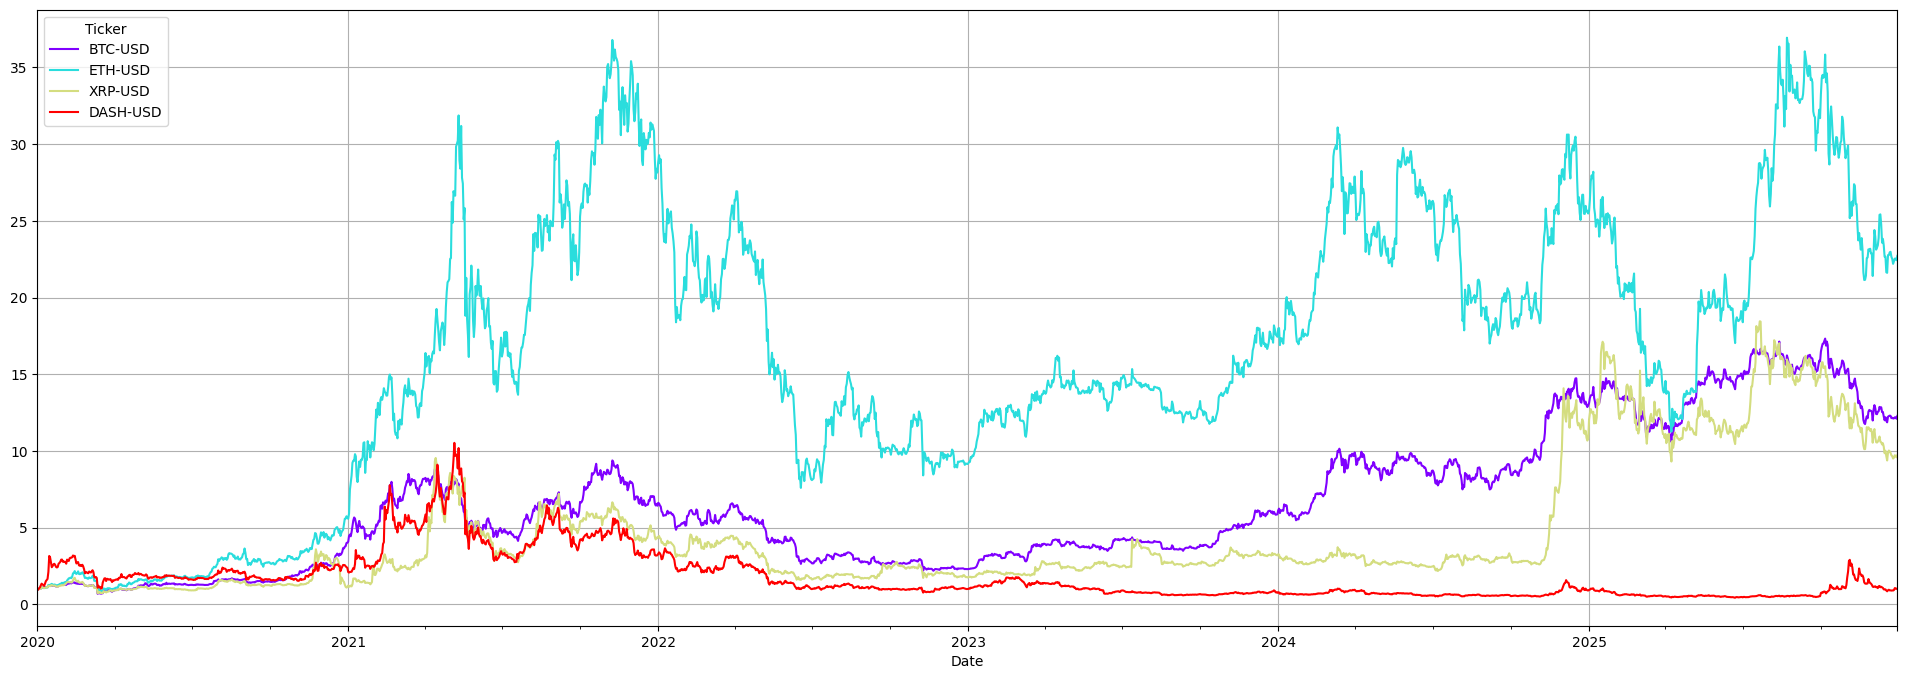

In [3]:
mudanca_proporcional = fechamento / fechamento.iloc[0,:]
cores = cm.rainbow(np.linspace(0, 1, len(moedas)))
mudanca_proporcional.fillna(1).plot.line(figsize=(24, 8), grid=True, color=cores)

mudanca_proporcional.head()

Por questões de simplicidade, será assumido que uma carteira inicial é composta com todas as criptomoedas apresentadas até aqui, de maneira proporcional. Ou seja, como foram apresentadas 4 criptomoedas, cada uma delas terá uma composição de 25% (25% x 4 = 100%) da carteira.

Com esta composição inicial, esta carteira apresentaria a evolução abaixo.

array([0.25, 0.25, 0.25, 0.25])

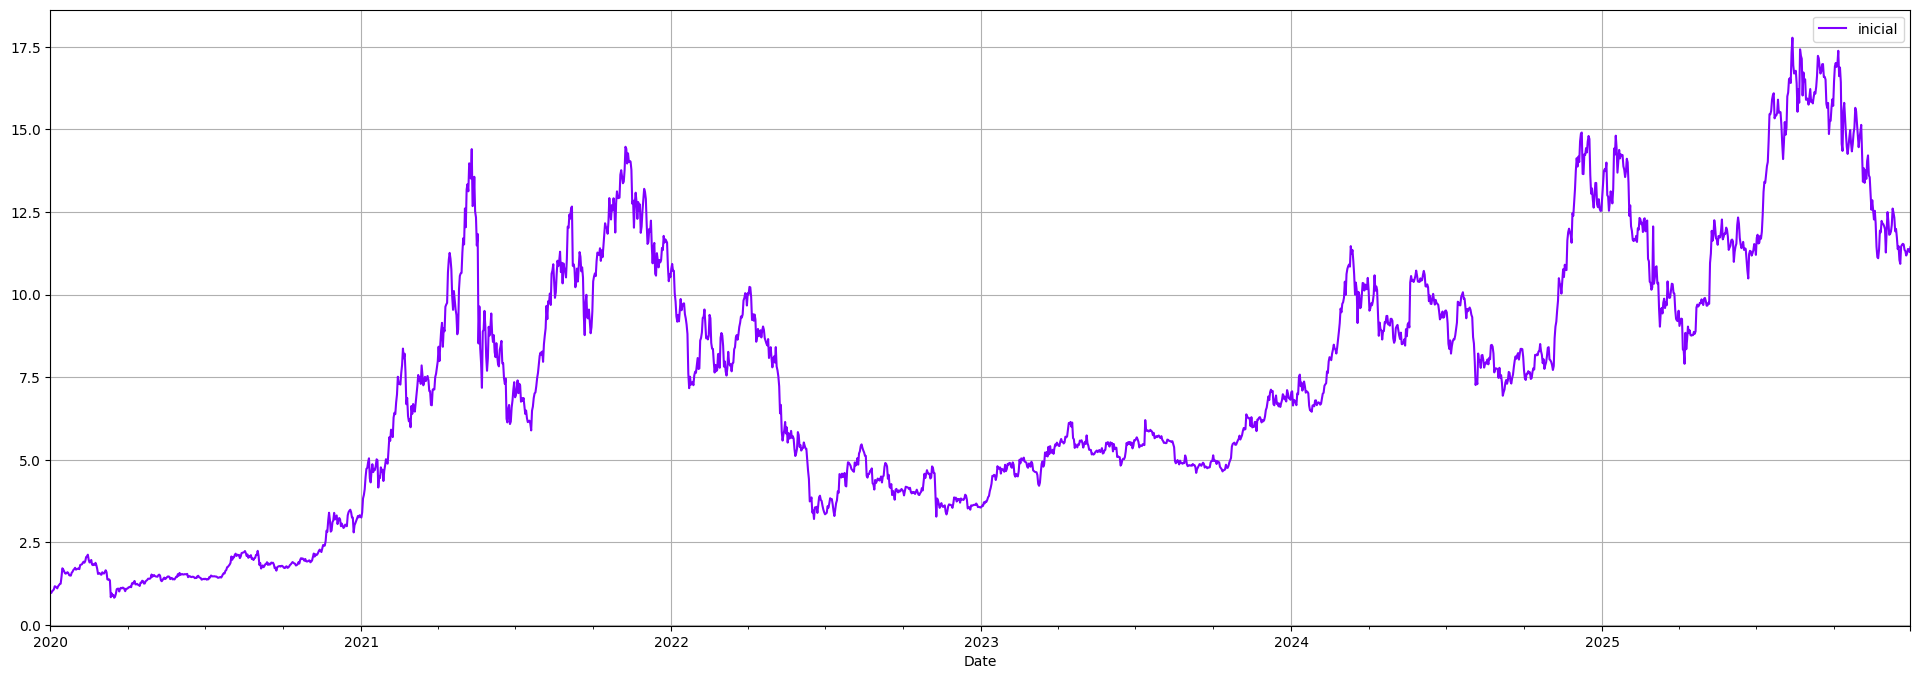

In [4]:
carteira_inicial = np.array([1.0/len(moedas) for i in range(len(moedas))])
evolucao = pd.DataFrame(dict(inicial = np.sum(mudanca_proporcional * carteira_inicial, axis=1)))

evolucao.plot.line(figsize=(24, 8), grid=True, color=cores)
carteira_inicial

Diferente do trecho de código anterior, abaixo será calculado o retorno percentual entre um dia corrente e o dia imediatamente anterior a ele. Ou seja, na tabela apresentada abaixo os valores em `2025-12-31`, apresentam a mudança percentual ocorrida entre `2020-01-01` e `2025-12-31`.

Esta informação é útil para medir a mudança percentual em elementos em série temporal. Que será útil para cálculos futuros como **retorno esperado, risco e índice de sharpe**.

Ticker,BTC-USD,ETH-USD,XRP-USD,DASH-USD
Date,,,,
2025-12-21,0.003144,0.008071,-0.005375,-0.045177
2025-12-22,-0.001486,0.001486,-0.010015,0.002330
2025-12-23,-0.012160,-0.014204,-0.015739,-0.016077
2025-12-24,0.002265,-0.006001,-0.006218,0.013989
2025-12-25,-0.004306,-0.014262,-0.015762,-0.008667
2025-12-26,0.000764,0.007634,0.006075,0.034905
2025-12-27,0.005736,0.007606,0.016218,0.135269
2025-12-28,0.000384,0.000193,-0.004535,-0.012637
2025-12-29,-0.007943,-0.004758,-0.008923,-0.036599


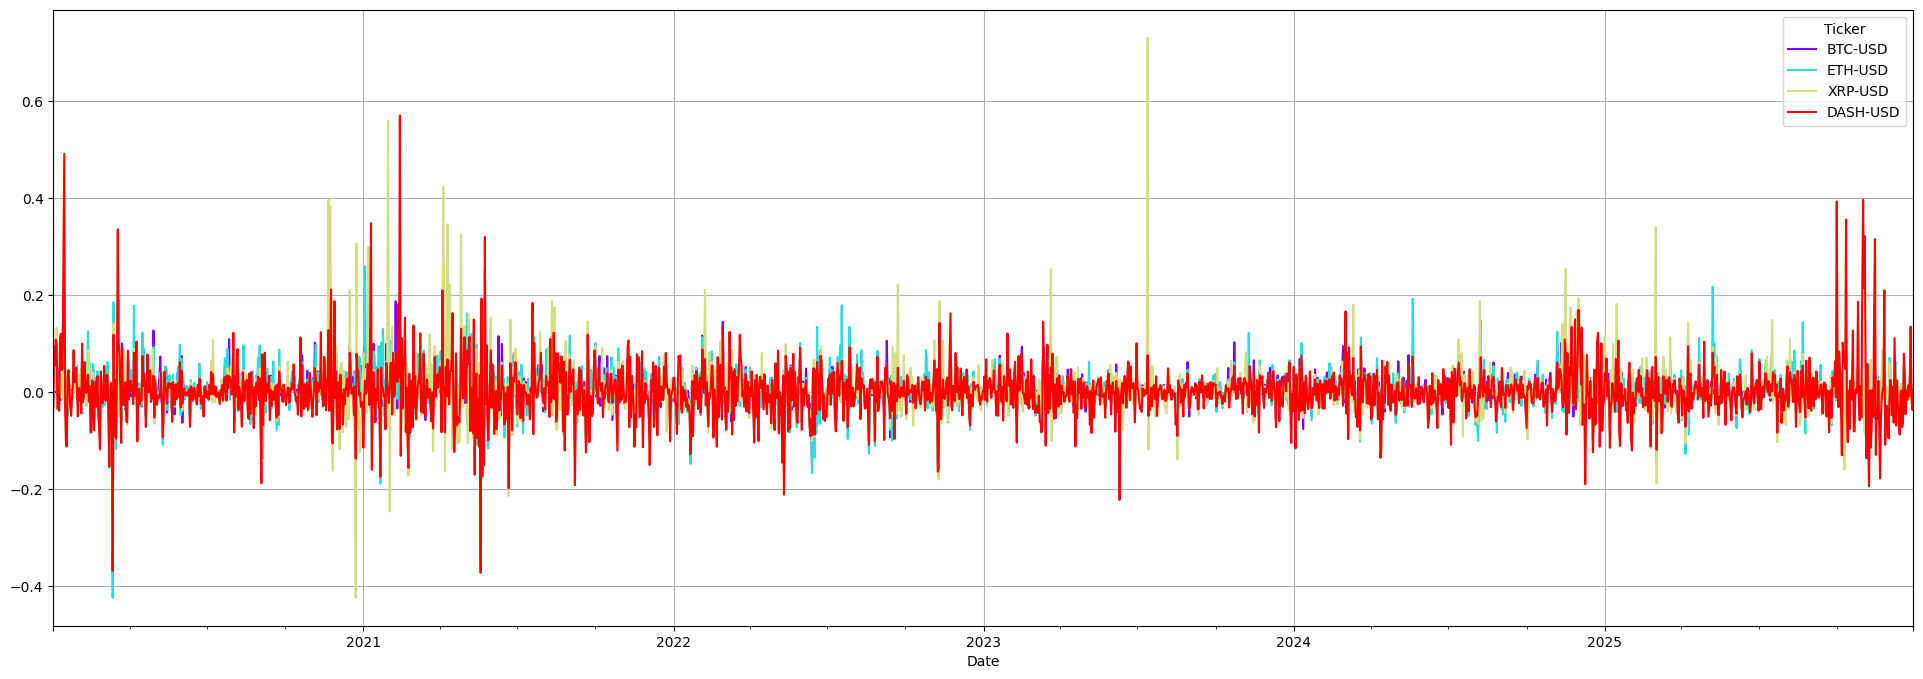

In [5]:
retorno_percentual = fechamento.pct_change().dropna()
retorno_percentual.plot.line(figsize=(24, 8), grid=True, color=cores)
retorno_percentual.tail(10)

## Risco e Retorno

A gestão de investimentos tem incorporada uma relação clara entre risco e retorno. O retorno esperado pelo investidor está relacionado com o risco que pretende correr.  Risco é a probabilidade de o retorno efetivo de um investimento ser diferente do retorno esperado (inicialmente) do mesmo, ou seja, o risco é uma incerteza e ao prolongar-se no tempo mais incerto se torna.

Esta atitude tomada pelo investidor depende do seu perfil de risco, no caso de ser avesso ao risco irá optar por uma carteira com menor risco, logo menor retorno esperado, se for propenso ao risco irá optar neste caso por uma carteira de maior risco, logo maior retorno esperado. O perfil do investidor será diferente para cada pessoa com base nas características individuais a aversão pelo risco. 

De forma prática, um investimento em ações está suscetível a um alto risco, enquanto um investimento em título públicos apresentam um risco mais baixo. Sendo assim, uma boa carteira de investimentos pode conter, para um mesmo nível de risco, um percentual investido em ações e títulos e ainda assim apresentar um retorno esperado maior que uma aplicação apresentando somente títulos (ou ações). Deste modo, para um mesmo nível de risco existe uma possível carteira alternativa que tem melhor retorno esperado. 

### Exemplificando retorno

O retorno esperado da carteira é calculado como uma soma ponderada dos retornos dos ativos individuais. Se uma carteira contivesse quatro ativos igualmente ponderados com retornos esperados de 4, 6, 10 e 14%, o retorno esperado da carteira seria:

`(4% x 25%) + (6% x 25%) + (10% x 25%) + (14% x 25%) = 8.5%`

No caso analisado das 4 criptomoedas selecionadas e igualmente ponderadas, o cálculo seria a composição da carteira inicial (25% para cada ativo) multiplicado pela média aritmética dos retornos percentuais.

In [6]:
retorno_inicial = np.dot(retorno_percentual.mean(), carteira_inicial)
retorno_inicial

np.float64(0.0020166394888599154)

### Exemplificando risco

Usualmente, o risco de um ativo financeiro é medido pelo seu desvio-padrão. Entretanto, um dos principais pontos levantados na [teoria de Markowitz](https://pt.wikipedia.org/wiki/Teoria_moderna_do_portf%C3%B3lio) é que o risco de um ativo medido isoladamente torna-se diferente quando esse ativo é incluso em uma carteira.

Portanto, não se pode calcular o desvio-padrão de uma carteira simplesmente somando ou obtendo a média dos desvios de cada ativo isoladamente (como feito para o cálculo do valor esperado).

O risco da carteira é uma função complicada das variações de cada ativo e da covariância de cada par de ativos. A covariância é uma medida que mostra o quão relacionados os ativos são entre si. Esta medida ajudará a encontrar a composição apropriada. Idealmente a composição de ativos não deve ser correlacionada, deste modo, se um ativo tiver uma tendência negativa outro deverá ter uma positiva e o retorno será balanceado. 

Usando os valores históricos de retorno percentual para calcular a covariância de todas as criptomoedas resultará em uma tabela de 64 (8 x 8) elementos.

In [7]:
carteira_cov = retorno_percentual.cov()
carteira_cov

Ticker,BTC-USD,ETH-USD,XRP-USD,DASH-USD
Ticker,,,,
BTC-USD,0.001019,0.001110,0.000989,0.001053
ETH-USD,0.001110,0.001827,0.001396,0.001478
XRP-USD,0.000989,0.001396,0.003052,0.001558
DASH-USD,0.001053,0.001478,0.001558,0.003199


Para calcular o risco de uma carteira de quatro ativos, a seguinte fórmula será utilizada:

$$\sigma_p = \sqrt{w^T \cdot C \cdot w}$$

onde $w$ é a proporção de cada ativo na carteira (no exemplo atual, 25% para cada ativo) e $C$ é a matriz de covariância, já definida na variável `carteira_cov`.

In [8]:
risco_inicial = np.sqrt(np.dot(carteira_inicial.T, np.dot(carteira_cov, carteira_inicial)))
risco_inicial

np.float64(0.03894294337577104)

### Índice Sharpe

O índice de Sharpe é simplesmente uma medida do desempenho dos retornos de um investimento, dado seu risco. Essa relação ajusta os retornos de um investimento, o que torna possível comparar diferentes investimentos em uma escala que incorpora o risco. Sem essa escala de comparação, seria virtualmente impossível comparar diferentes investimentos com diferentes combinações e seus riscos e retornos associados.

O índice de sharpe é calculado, de forma simplificada, por:

In [9]:
sharpe_inicial = retorno_inicial / risco_inicial
sharpe_inicial

np.float64(0.0517844650159289)

## Simulações de Carteiras

Após as principais medidas levantadas neste notebook já esclarecidas (**retorno esperado, risco e índice de sharpe**), o próximo passo é iniciar uma série de simulações para criar uma série de carteiras, com proporções de ativos diferentes, e montar um comparativo entre as suas principais medidas.

O trecho abaixo, define uma função chamada `gerar_distribuicao_carteira`, que tem por objetivo montar carteiras (proporções de ativos) de maneira aleatória e suas principais métricas.

Ao final, a função é chamada com um total de 10000 simulações de parâmetro. O resultado desta amostra gerada e armazenada na variável `df`, como pode ser visto abaixo.

In [ ]:
# Aqui está sendo feito o merge dos dois Dfs, o que é necessário para a construção do gráfico de risco x retorno


def gerar_distribuicao_carteira(ativos, retorno_percentual, cov, num_simulacoes):
    retornos = []
    volatilidades = []
    sharpes = []
    pesos_portfolio = []

    num_ativos = len(ativos)
    media_variacao = retorno_percentual.mean()

    np.random.seed(4765)
    for s in range(0, num_simulacoes):
        pesos = np.random.random(num_ativos)
        pesos /= pesos.sum()
        retorno = np.dot(pesos, media_variacao)
        volatilidade = np.sqrt(np.dot(pesos.T, np.dot(cov, pesos)))
        sharpe = retorno / volatilidade

        retornos.append(retorno)
        volatilidades.append(volatilidade)
        sharpes.append(sharpe)
        pesos_portfolio.append(pesos)

    # um dicionario de Retorno e Risco para cada carteira
    portfolio = {'Retornos': retornos, 'Riscos': volatilidades, 'Sharpes': sharpes}

    # acrescentando a composicao de cada moeda da carteira ao dicionario
    for counter, at in enumerate(ativos):
        portfolio[at + ' comp'] = [peso[counter] for peso in pesos_portfolio]

    # transformando o dicionario gerado em um Dataframe
    df = pd.DataFrame(portfolio)
    column_order = ['Retornos', 'Riscos', 'Sharpes'] + [at + ' comp' for at in ativos]    
    return df[column_order].sort_values(['Retornos']).reset_index().set_index('index')
  
df = gerar_distribuicao_carteira(moedas, retorno_percentual, carteira_cov, 10000)
df.head(20)

,Retornos,Riscos,Sharpes,BTC-USD comp,ETH-USD comp,XRP-USD comp,DASH-USD comp
index,,,,,,,
8245,0.001611,0.053870,0.029898,0.029885,0.020105,0.034530,0.915481
4600,0.001613,0.048347,0.033366,0.196436,0.016266,0.021846,0.765452
7125,0.001614,0.048658,0.033164,0.186087,0.016996,0.022936,0.773981
9202,0.001614,0.046896,0.034426,0.240274,0.026413,0.009626,0.723687
2075,0.001624,0.047360,0.034283,0.220222,0.008035,0.037516,0.734226
707,0.001627,0.051451,0.031626,0.087160,0.024509,0.042152,0.846178
2332,0.001628,0.052930,0.030750,0.042609,0.023656,0.048384,0.885351
3612,0.001631,0.045902,0.035527,0.256928,0.037715,0.015621,0.689736
1396,0.001633,0.037496,0.043550,0.575807,0.006972,0.008440,0.408781


Em seguida é plotado um gráfico de Retorno Esperado x Risco para cada um das carteiras geradas na simulação. 
Cada ponto deste gráfico é colorido com o valor do seu índice de sharpe (verde serão os valores maiores, enquanto vermelho os valores mais baixos).

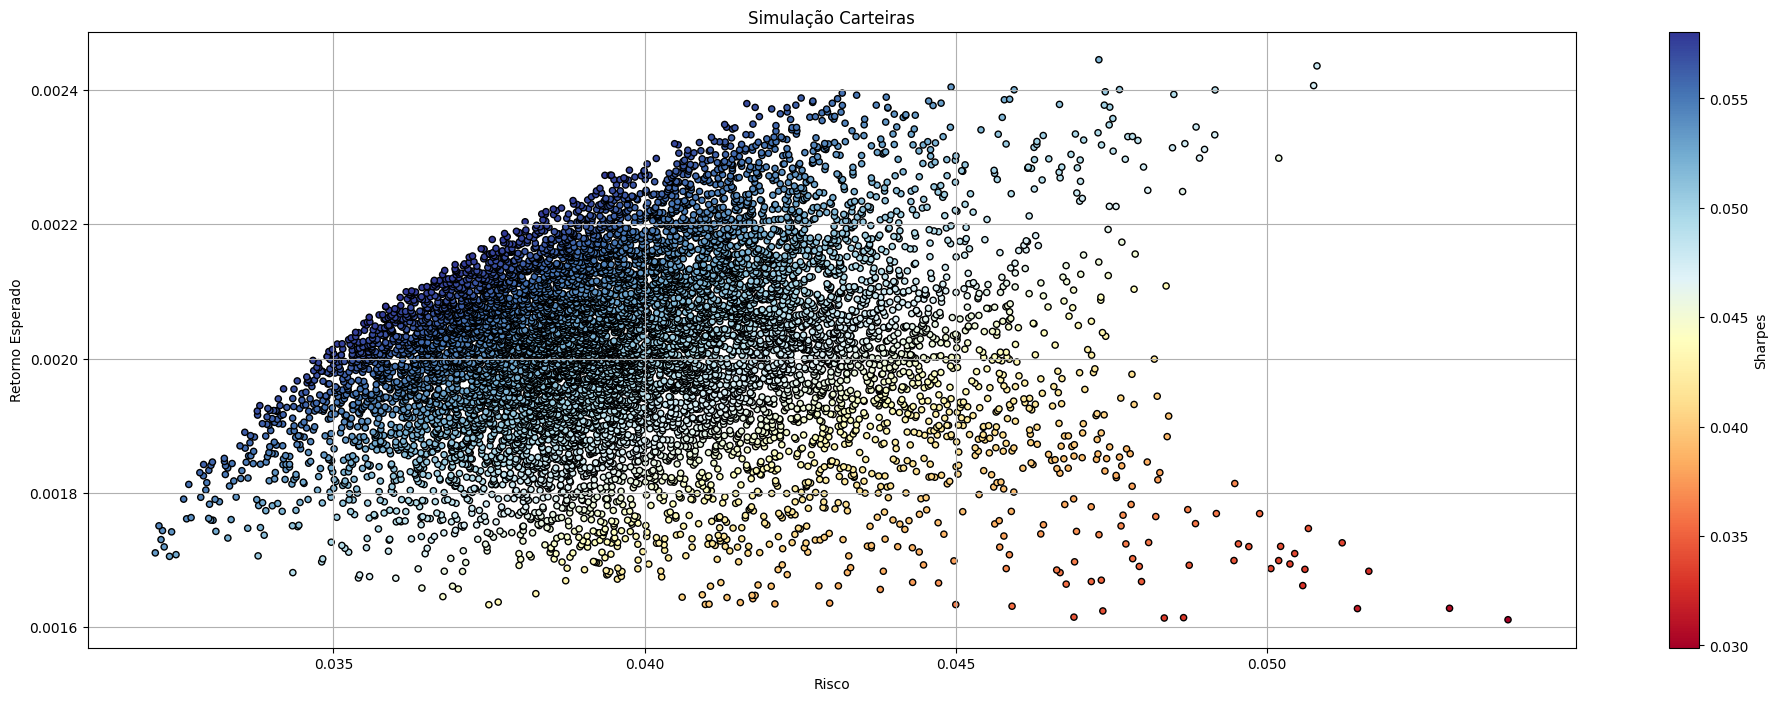

In [11]:
df.plot.scatter(x='Riscos', y='Retornos', c='Sharpes', cmap='RdYlBu', edgecolors='black', 
                figsize=(24, 8), grid=True, sharex=False)
plt.xlabel('Risco')
plt.ylabel('Retorno Esperado')
plt.title(u'Simulação Carteiras')
plt.show()

In [ ]:
# Exporta o dataframe final da análise de carteira para CSV

output_file = 'carteira_final.csv'
df.to_csv(output_file, index=True, index_label='index')
print(f'Arquivo exportado para {output_file}')

Arquivo exportado para carteira_final.csv
